In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
from scipy.optimize import curve_fit
from scipy.stats import moyal
import pickle

Delta t

In [2]:
dtpath = '/raid1/genli/Data_D2O/M1_data/analysis_28727-28895_step1_M1_20260303-163716/MASTER_RESULTS/aggregated_delta_t_step1.pkl'
# dtpath = '/raid1/genli/Data_D2O/M2_data/analysis_4598-4766_step1_M2_20260302-225545/MASTER_RESULTS/aggregated_delta_t_step1.pkl'
#auto-detect the module (M1 or M2) from the path
if 'M1' in dtpath:
    module = '1'
elif 'M2' in dtpath:
    module = '2'
#auto-detect the run range from the path
import re
run_range_match = re.search(r'analysis_(\d+-\d+)_step1', dtpath)

import pickle

def load_aggregated_data(path):
    try:
        with open(path, 'rb') as f:
            return pickle.load(f), 'pickle.load'
    except Exception as pickle_err:
        last_pickle_err = pickle_err

    try:
        import torch
        return torch.load(path, map_location='cpu'), 'torch.load'
    except Exception as torch_err:
        last_torch_err = torch_err

    try:
        import joblib
        return joblib.load(path), 'joblib.load'
    except Exception as joblib_err:
        raise RuntimeError(
            'Failed to load file with pickle, torch, and joblib.\n'
            f'pickle error: {last_pickle_err}\n'
            f'torch error: {last_torch_err}\n'
            f'joblib error: {joblib_err}'
        )

data, loader_used = load_aggregated_data(dtpath)
print(f'Loaded with: {loader_used}')
if not isinstance(data, dict):
    raise TypeError(f'Expected loaded object to be dict, got {type(data)}')
print(data.keys())

#load centers, histograms and errors
centers = data['centers']
histograms = data['histograms']
errors = data['errors']

Loaded with: pickle.load
dict_keys(['centers', 'histograms', 'errors', 'fit_model', 'fit_params', 'fit_stats'])


In [3]:
#print fit_model and fit_params
print(data['fit_model'])
print(data['fit_params'])

A*exp(-(t-t0)/tau)+c
{'A': 43757.31348978099, 'tau': 2079.1972625410576, 'c': 1.6634537511003335e-13, 't0': 2560.0, 'A_err': 93.05943759640944, 'tau_err': 7.406050909896869, 'c_err': 25.686834781795504}


In [4]:
print(centers)

[ 2480.  2640.  2800.  2960.  3120.  3280.  3440.  3600.  3760.  3920.
  4080.  4240.  4400.  4560.  4720.  4880.  5040.  5200.  5360.  5520.
  5680.  5840.  6000.  6160.  6320.  6480.  6640.  6800.  6960.  7120.
  7280.  7440.  7600.  7760.  7920.  8080.  8240.  8400.  8560.  8720.
  8880.  9040.  9200.  9360.  9520.  9680.  9840. 10000. 10160. 10320.
 10480. 10640. 10800. 10960. 11120. 11280. 11440. 11600. 11760. 11920.
 12080. 12240. 12400. 12560. 12720. 12880. 13040. 13200. 13360. 13520.
 13680. 13840. 14000. 14160. 14320. 14480. 14640. 14800. 14960. 15120.
 15280. 15440. 15600. 15760. 15920. 16080. 16240. 16400. 16560. 16720.
 16880. 17040. 17200. 17360. 17520. 17680. 17840. 18000. 18160. 18320.
 18480. 18640. 18800. 18960. 19120. 19280. 19440. 19600. 19760. 19920.
 20080. 20240. 20400. 20560. 20720. 20880. 21040. 21200. 21360. 21520.
 21680. 21840. 22000. 22160. 22320. 22480. 22640. 22800. 22960. 23120.
 23280. 23440. 23600. 23760. 23920. 24080. 24240. 24400. 24560. 24720.
 24880

In [5]:
# two single-exponential fits with user-fixed first boundary and 2σ second boundary
from scipy.optimize import curve_fit

def _pick_series(series_like, name, preferred_key=None):
    if isinstance(series_like, dict):
        if preferred_key is not None and preferred_key in series_like:
            key = preferred_key
        elif 'all' in series_like:
            key = 'all'
        elif 'total' in series_like:
            key = 'total'
        else:
            key = next(iter(series_like))
        print(f"Using {name}['{key}']")
        return np.asarray(series_like[key], dtype=float), key
    return np.asarray(series_like, dtype=float), preferred_key

# load arrays
centers_arr, key = _pick_series(centers, 'centers')
hist_arr, key = _pick_series(histograms, 'histograms', preferred_key=key)
err_arr, _ = _pick_series(errors, 'errors', preferred_key=key)

# keep valid points
mask = np.isfinite(centers_arr) & np.isfinite(hist_arr) & np.isfinite(err_arr) & (err_arr > 0)
x = centers_arr[mask]
y = hist_arr[mask]
sigma = err_arr[mask]

if len(x) < 40:
    raise ValueError('Need at least ~40 bins to fit two regions reliably.')

# fit model for each region: A*exp(-(x-x0)/tau)+C
def single_exp_local(xlocal, A, tau, C, x0):
    return A * np.exp(-(xlocal - x0) / tau) + C

def fit_single_region(xr, yr, sr):
    x0 = float(xr[0])
    C0 = max(0.0, float(np.percentile(yr, 10)))
    A0 = max(float(np.max(yr) - C0), 1.0)
    tau0 = max(float((xr[-1] - xr[0]) / 2.0), 100.0)

    def model_wrap(xlocal, A, tau, C):
        return single_exp_local(xlocal, A, tau, C, x0)

    p0 = [A0, tau0, C0]
    lb = [0.0, 50.0, 0.0]
    ub = [np.inf, 2.0e5, np.inf]

    popt, pcov = curve_fit(
        model_wrap, xr, yr, p0=p0, sigma=sr, absolute_sigma=True,
        bounds=(lb, ub), method='trf', max_nfev=100000
    )

    residual = yr - model_wrap(xr, *popt)
    chi2 = float(np.sum((residual / sr) ** 2))
    dof = max(len(xr) - len(popt), 1)
    red_chi2 = chi2 / dof
    return x0, popt, pcov, red_chi2

# 1) fixed boundary between first-fit and transition
transition_start = 14000.0
i_split = int(np.searchsorted(x, transition_start, side='left'))

min_fit_pts = 12
if i_split < min_fit_pts:
    raise ValueError(f'Not enough bins below {transition_start} ns for first fit.')

# first region fit (x < 14000 ns)
x1, y1, s1 = x[:i_split], y[:i_split], sigma[:i_split]
x01, popt1, pcov1, redchi1 = fit_single_region(x1, y1, s1)
A1_fit, tau1_fit, C1_fit = popt1
perr1 = np.sqrt(np.clip(np.diag(pcov1), 0.0, np.inf))
tau1_err = float(perr1[1])

# 2) second boundary = first sustained 2σ deviation from section-1 fit line
model1_all = A1_fit * np.exp(-(x - x01) / tau1_fit) + C1_fit
pull1_all = (y - model1_all) / sigma

idx_after = np.where(x >= transition_start)[0]
if len(idx_after) == 0:
    raise ValueError('No bins at or above 14000 ns found.')

consecutive_needed = 3
sigma_threshold = 2.0
j_split = None
run = 0
for idx in idx_after:
    if np.abs(pull1_all[idx]) >= sigma_threshold:
        run += 1
    else:
        run = 0
    if run >= consecutive_needed:
        j_split = idx - consecutive_needed + 1
        break

# fallback: if no 2σ crossing, start section-2 at end of available range block
if j_split is None:
    j_split = min(i_split + max(6, int(0.08 * len(x))), len(x) - min_fit_pts)

if j_split <= i_split:
    j_split = min(i_split + 1, len(x) - min_fit_pts)

transition_end = float(x[j_split - 1])

# second region fit (x > transition_end)
x2, y2, s2 = x[j_split:], y[j_split:], sigma[j_split:]
if len(x2) < min_fit_pts:
    raise ValueError('Not enough bins in second region after transition for second fit.')

x02, popt2, pcov2, redchi2 = fit_single_region(x2, y2, s2)
A2_fit, tau2_fit, C2_fit = popt2
perr2 = np.sqrt(np.clip(np.diag(pcov2), 0.0, np.inf))
tau2_err = float(perr2[1])

print(f'First fit region:      x < {transition_start:.1f} ns')
print(f'Transition region:     {transition_start:.1f} to {transition_end:.1f} ns')
print(f'Second fit region:     x > {transition_end:.1f} ns')
print('---')
print(f'tau1 = {tau1_fit:.2f} ± {tau1_err:.2f} ns   (reduced chi2 = {redchi1:.2f})')
print(f'tau2 = {tau2_fit:.2f} ± {tau2_err:.2f} ns   (reduced chi2 = {redchi2:.2f})')

Using histograms['Master Runs 28727-28895']
Using errors['Master Runs 28727-28895']
First fit region:      x < 14000.0 ns
Transition region:     14000.0 to 18160.0 ns
Second fit region:     x > 18160.0 ns
---
tau1 = 2085.06 ± 4.08 ns   (reduced chi2 = 4.85)
tau2 = 2332.59 ± 315.81 ns   (reduced chi2 = 1.49)


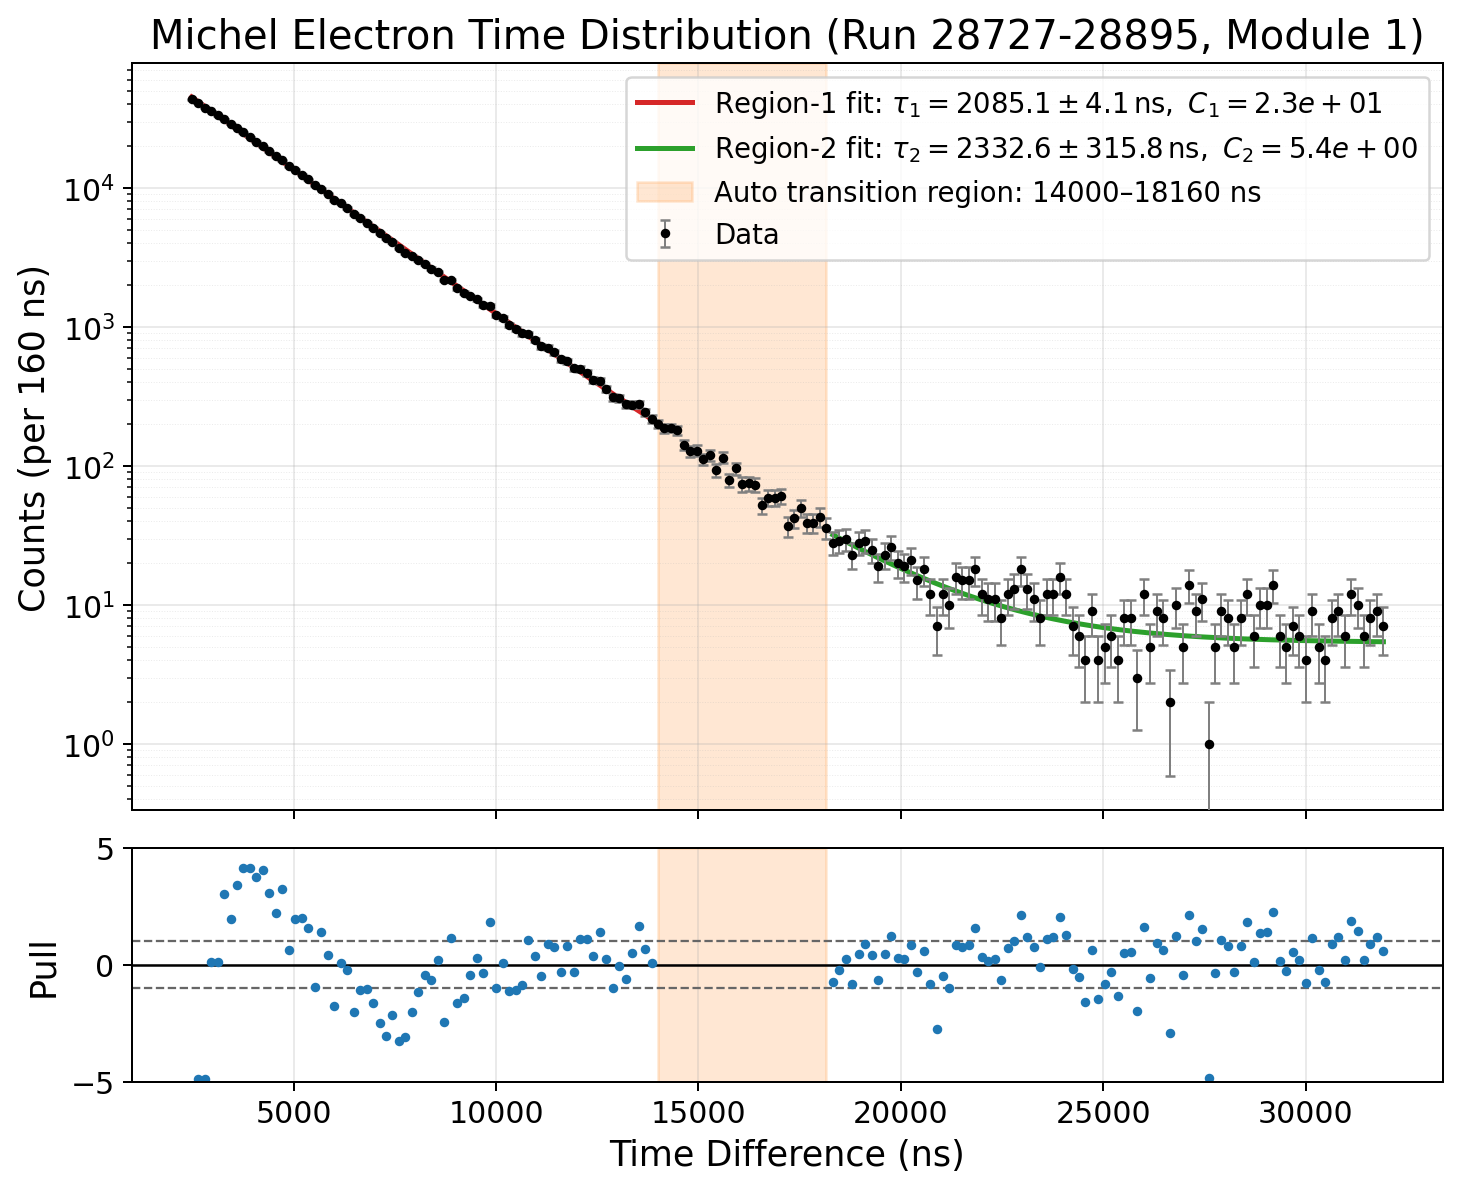

In [6]:
# thesis-ready plot: two single-exponential fits + automatic transition band
plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 11
})

fig, (ax, ax_pull) = plt.subplots(
    2, 1, figsize=(8.0, 6.5), dpi=180,
    gridspec_kw={'height_ratios': [3.2, 1.0], 'hspace': 0.03},
    sharex=True,
    constrained_layout=True
)

# data
data_handle = ax.errorbar(
    x, y, yerr=sigma, fmt='o', ms=2.8, lw=0.8, capsize=2.0,
    color='black', ecolor='gray', elinewidth=0.8, label='Data', zorder=3
)

# region 1 fit curve
xfit1 = np.linspace(x1[0], x1[-1], 500)
yfit1 = A1_fit * np.exp(-(xfit1 - x01) / tau1_fit) + C1_fit
fit1_handle, = ax.plot(
    xfit1, yfit1, color='tab:red', lw=2.0,
    label=rf'Region-1 fit: $\tau_1={tau1_fit:.1f}\pm{tau1_err:.1f}\,\mathrm{{ns}},\ C_1={C1_fit:.1e}$',
    zorder=2
)

# region 2 fit curve
xfit2 = np.linspace(x2[0], x2[-1], 500)
yfit2 = A2_fit * np.exp(-(xfit2 - x02) / tau2_fit) + C2_fit
fit2_handle, = ax.plot(
    xfit2, yfit2, color='tab:green', lw=2.0,
    label=rf'Region-2 fit: $\tau_2={tau2_fit:.1f}\pm{tau2_err:.1f}\,\mathrm{{ns}},\ C_2={C2_fit:.1e}$',
    zorder=2
)

# transition band
transition_label = f'Auto transition region: {transition_start:.0f}–{transition_end:.0f} ns'
ax.axvspan(transition_start, transition_end, color='tab:orange', alpha=0.18, label=transition_label)
binwidth = float(x[1] - x[0]) if len(x) > 1 else 100.0
ax.set_ylabel(f'Counts (per {binwidth:.0f} ns)')
ax.set_yscale('log')
ax.set_title(f'Michel Electron Time Distribution (Run {run_range_match.group(1)}, Module {module})')
ax.legend(loc='upper right', frameon=True)
ax.grid(True, which='major', linestyle='-', linewidth=0.6, alpha=0.35)
ax.grid(True, which='minor', linestyle=':', linewidth=0.4, alpha=0.25)

# pull panel relative to piecewise model (transition bins omitted)
piecewise_model = np.full_like(y, np.nan, dtype=float)
left_mask = x < transition_start
right_mask = x > transition_end
piecewise_model[left_mask] = A1_fit * np.exp(-(x[left_mask] - x01) / tau1_fit) + C1_fit
piecewise_model[right_mask] = A2_fit * np.exp(-(x[right_mask] - x02) / tau2_fit) + C2_fit
pull = np.full_like(y, np.nan, dtype=float)
valid_pull = np.isfinite(piecewise_model)
pull[valid_pull] = (y[valid_pull] - piecewise_model[valid_pull]) / sigma[valid_pull]

ax_pull.axhline(0, color='black', lw=1.0)
ax_pull.axhline(1, color='0.4', lw=0.9, ls='--')
ax_pull.axhline(-1, color='0.4', lw=0.9, ls='--')
ax_pull.axvspan(transition_start, transition_end, color='tab:orange', alpha=0.18)
ax_pull.plot(x[valid_pull], pull[valid_pull], 'o', ms=2.8, color='tab:blue')
ax_pull.set_ylabel('Pull')
ax_pull.set_xlabel('Time Difference (ns)')
ax_pull.set_ylim(-5, 5)
ax_pull.grid(True, which='major', linestyle='-', linewidth=0.6, alpha=0.35)

# fig.savefig('michel_electron_two_region_fit_thesis.pdf', bbox_inches='tight')
fig.savefig(f'michel_electron_two_region_fit_run_{run_range_match.group(1)}_M{module}.png', dpi=300, bbox_inches='tight')
plt.show()

Spectrum

In [7]:
M1_spectrum_path = '/raid1/genli/Data_D2O/M1_data/analysis_28727-28895_step1_M1_20260303-163716/MASTER_RESULTS/aggregated_total_pe_step1.pkl'
M2_spectrum_path = '/raid1/genli/Data_D2O/M2_data/analysis_4598-4766_step1_M2_20260302-225545/MASTER_RESULTS/aggregated_total_pe_step1.pkl'

#load spectrum data for both M1 and M2 respectively, print the keys of the loaded data, and check if 'spectrum' key exists in both cases. 
#If does, plot the spectrum with error bars for both M1 and M2 on the same plot, using different colors and markers for each model. Plot the difference between the two spectra in a separate subplot below, with error bars representing the combined uncertainties. Label the axes and include a legend to distinguish between the two models. Save the plot as 'michel_electron_spectrum_comparison.png'.
#Also apply Gaussian fit to both spectr, cover the peak and half-maximum regions, and report the peak location and sigma with uncertainties in the plot legend.

M1 loaded with: pickle.load
M2 loaded with: pickle.load
M1 keys: ['centers', 'histograms', 'errors', 'fit_params']
M2 keys: ['centers', 'histograms', 'errors', 'fit_params']
'spectrum' in M1: False
'spectrum' in M2: False
Native M1 bin width: 20 P.E.
Native M2 bin width: 20 P.E.
Using plotted/fit bin width: 20 P.E.
Using x limits: (0, 800)
M1 FWHM fit window: [78.30, 240.95] (FWHM=162.65)
M2 FWHM fit window: [81.71, 371.75] (FWHM=290.04)


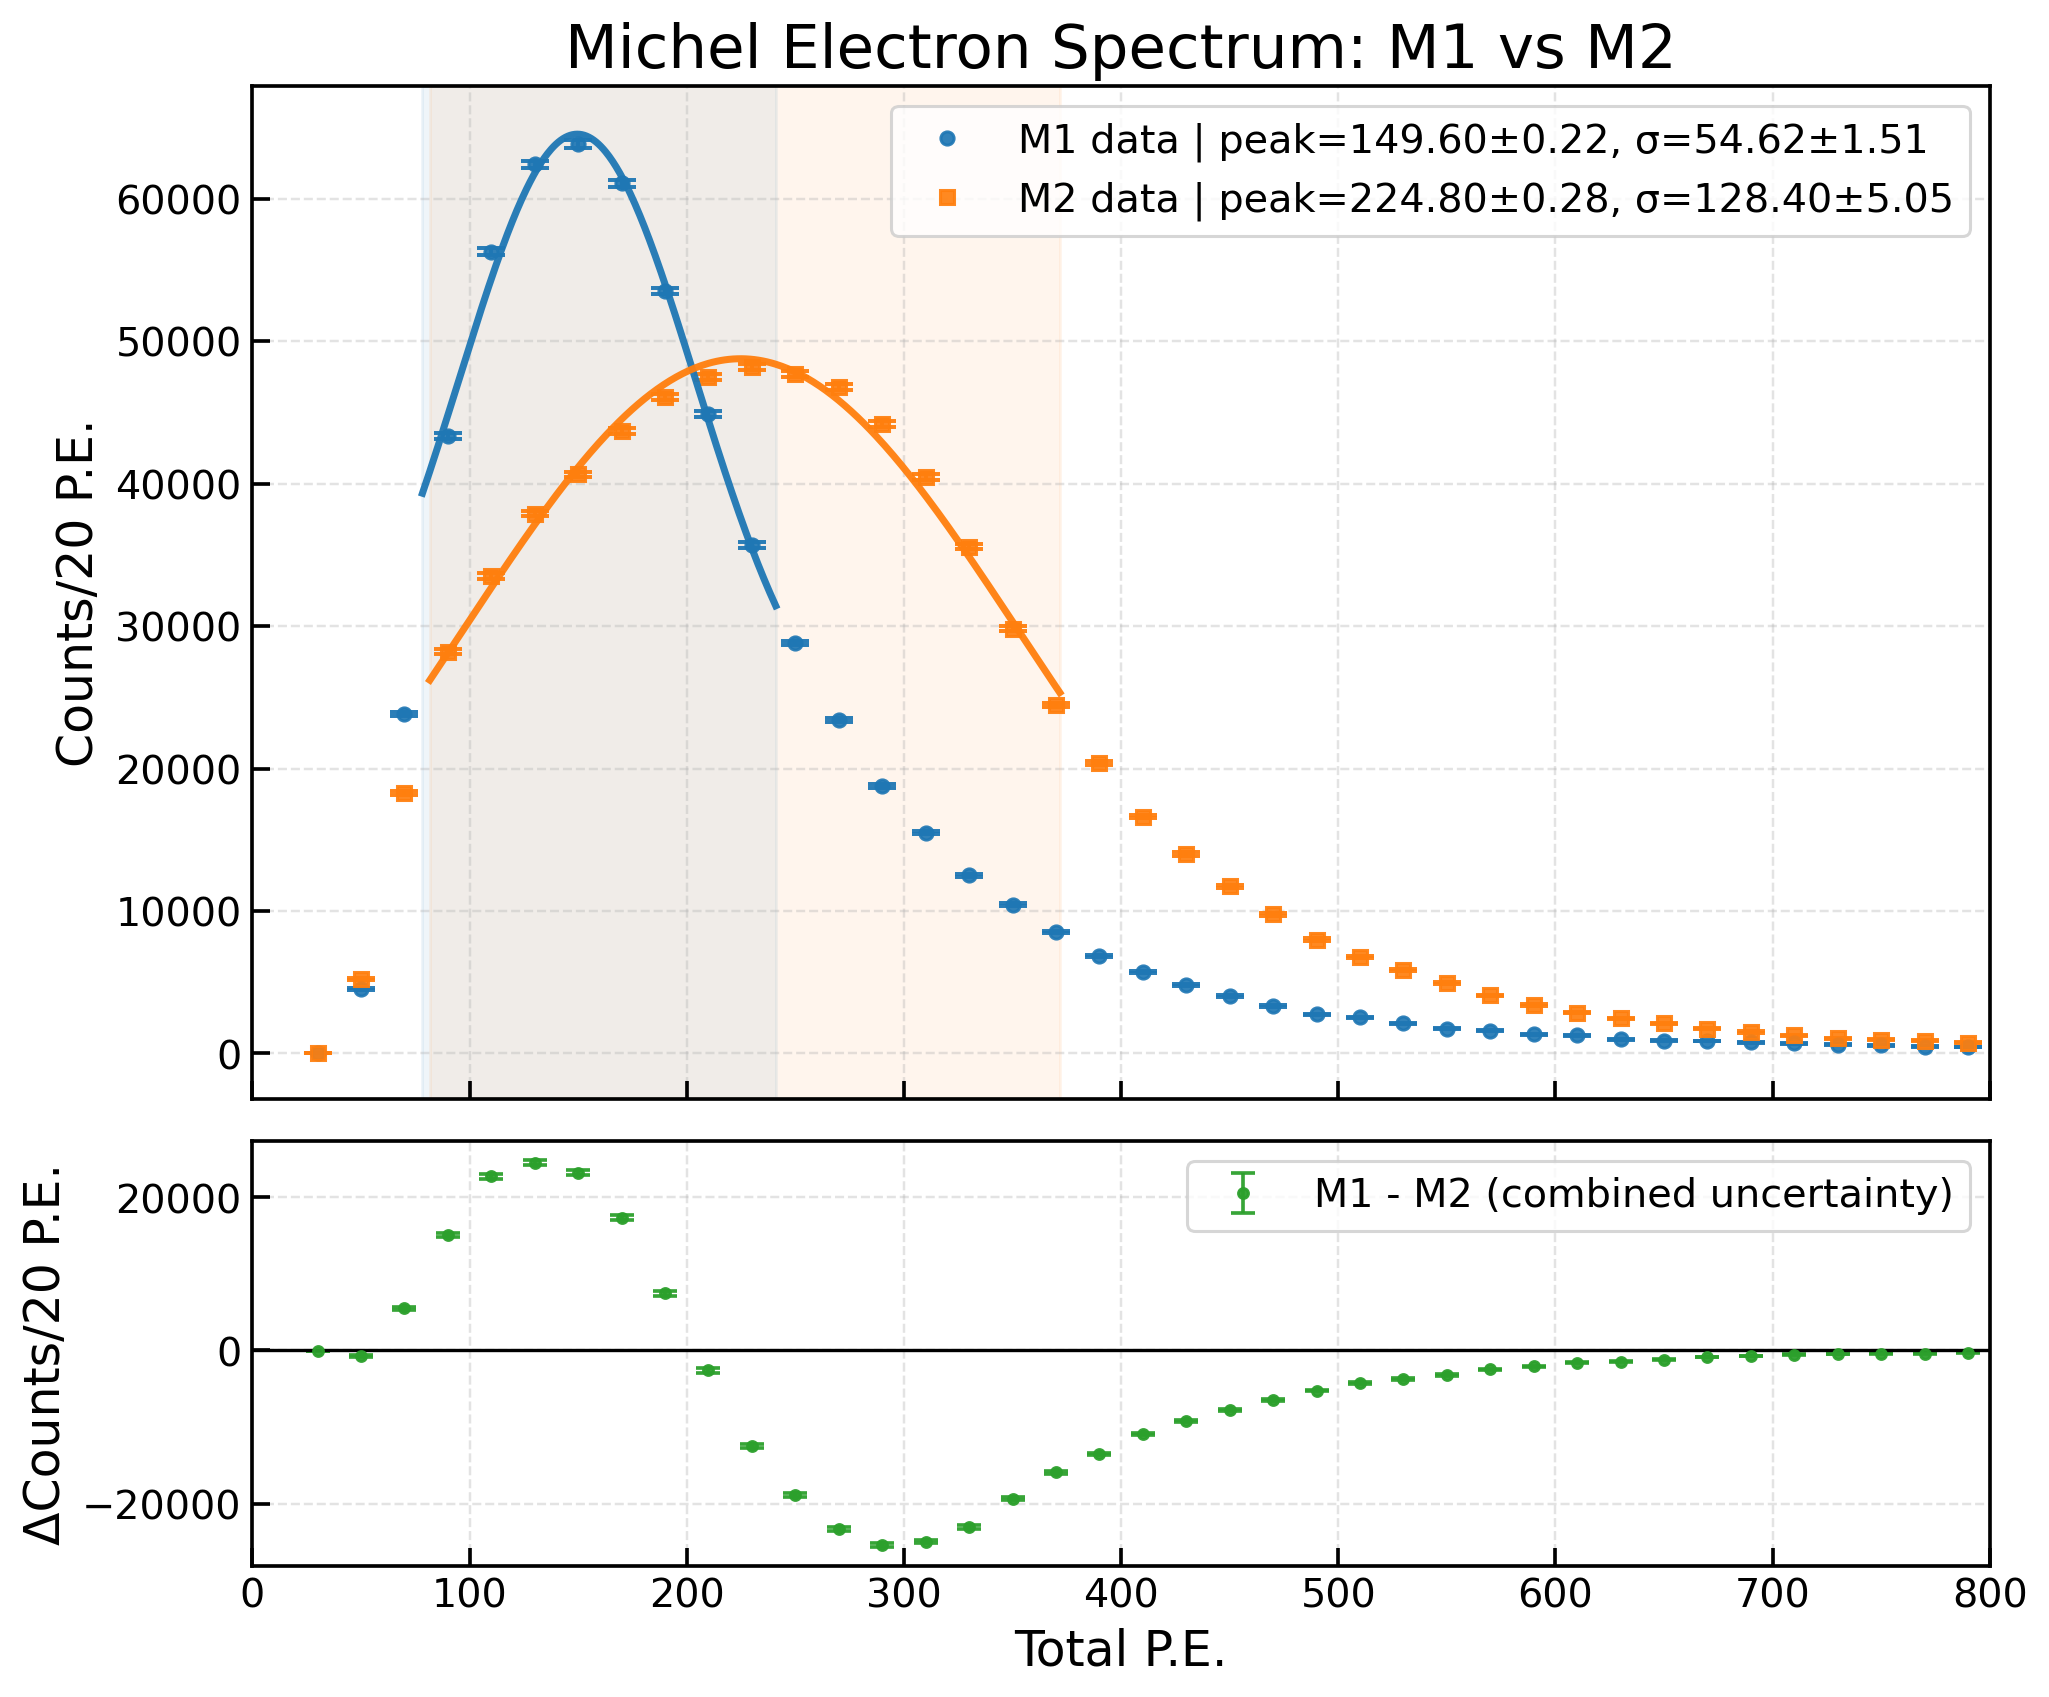

Saved: michel_electron_spectrum_comparison.png


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# User configuration
x_limits = (0, 800)  # Example: (0, 250)
target_bin_width = None  # Example: 5.0 ; use None to keep the native binning


def _pick_series(series_like, preferred_key=None):
    if isinstance(series_like, dict):
        if preferred_key is not None and preferred_key in series_like:
            key = preferred_key
        elif 'all' in series_like:
            key = 'all'
        elif 'total' in series_like:
            key = 'total'
        else:
            key = next(iter(series_like))
        return np.asarray(series_like[key], dtype=float), key
    return np.asarray(series_like, dtype=float), preferred_key


def _extract_spectrum_payload(data):
    x = None
    key = None
    for x_key in ['centers', 'bin_centers', 'bins', 'x', 'pe_centers']:
        if x_key in data:
            x, key = _pick_series(data[x_key])
            break

    y = None
    y_key_used = None
    if 'spectrum' in data:
        y, y_key_used = _pick_series(data['spectrum'], preferred_key=key)
    elif 'histograms' in data:
        y, y_key_used = _pick_series(data['histograms'], preferred_key=key)
    elif 'counts' in data:
        y, y_key_used = _pick_series(data['counts'], preferred_key=key)

    if y is None:
        raise KeyError("Could not find spectrum-like data. Expected one of: 'spectrum', 'histograms', 'counts'.")

    yerr = None
    if 'errors' in data:
        yerr, _ = _pick_series(data['errors'], preferred_key=y_key_used)
    elif 'uncertainties' in data:
        yerr, _ = _pick_series(data['uncertainties'], preferred_key=y_key_used)

    if yerr is None:
        yerr = np.sqrt(np.clip(y, 0, None))

    if x is None:
        x = np.arange(len(y), dtype=float)

    n = min(len(x), len(y), len(yerr))
    x = np.asarray(x[:n], dtype=float)
    y = np.asarray(y[:n], dtype=float)
    yerr = np.asarray(yerr[:n], dtype=float)

    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr) & (yerr > 0)
    return x[mask], y[mask], yerr[mask]


def _infer_bin_width(x):
    dx = np.diff(np.sort(np.unique(x)))
    dx = dx[np.isfinite(dx) & (dx > 0)]
    return float(np.median(dx)) if len(dx) else 1.0


def _apply_x_limits(x, y, yerr, limits):
    x_min, x_max = limits
    mask = np.ones_like(x, dtype=bool)
    if x_min is not None:
        mask &= x >= x_min
    if x_max is not None:
        mask &= x <= x_max
    return x[mask], y[mask], yerr[mask]


def _build_rebin_edges(arrays, target_width, limits):
    x_min_cfg, x_max_cfg = limits
    data_min = min(float(np.min(arr)) for arr in arrays)
    data_max = max(float(np.max(arr)) for arr in arrays)

    x_min = data_min if x_min_cfg is None else float(x_min_cfg)
    x_max = data_max if x_max_cfg is None else float(x_max_cfg)
    if x_max <= x_min:
        raise ValueError('x_limits must satisfy x_max > x_min.')

    n_bins = int(np.ceil((x_max - x_min) / target_width))
    edges = x_min + target_width * np.arange(n_bins + 1, dtype=float)
    if edges[-1] < x_max:
        edges = np.append(edges, x_max)
    else:
        edges[-1] = x_max
    return edges


def _rebin_to_edges(x, y, yerr, edges):
    order = np.argsort(x)
    x = x[order]
    y = y[order]
    yerr = yerr[order]

    bin_index = np.digitize(x, edges, right=False) - 1
    valid = (bin_index >= 0) & (bin_index < len(edges) - 1)
    bin_index = bin_index[valid]

    counts = np.bincount(bin_index, weights=y[valid], minlength=len(edges) - 1)
    err2 = np.bincount(bin_index, weights=yerr[valid] ** 2, minlength=len(edges) - 1)
    occupancy = np.bincount(bin_index, minlength=len(edges) - 1)

    centers = 0.5 * (edges[:-1] + edges[1:])
    keep = occupancy > 0
    return centers[keep], counts[keep], np.sqrt(err2[keep])


def _configure_binning(x, y, yerr, target_width, limits, native_width=None):
    if target_width is None:
        return _apply_x_limits(x, y, yerr, limits)

    if target_width <= 0:
        raise ValueError('target_bin_width must be positive.')

    if native_width is None:
        native_width = _infer_bin_width(x)

    if target_width < native_width - 1e-9:
        raise ValueError(
            f'target_bin_width={target_width:g} is smaller than the native bin width {native_width:g}. '
            'Use a value >= native width or None.'
        )

    return _rebin_to_edges(x, y, yerr, _build_rebin_edges([x], target_width, limits))


def gaussian_with_offset(x, A, mu, sigma, C):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + C


def gaussian_uncertainty_band(x, popt, pcov):
    A, mu, sigma, C = popt
    sigma = np.sign(sigma) * max(abs(sigma), 1e-12)

    z = (x - mu) / sigma
    exp_term = np.exp(-0.5 * z**2)

    dA = exp_term
    dmu = A * exp_term * ((x - mu) / (sigma**2))
    dsigma = A * exp_term * (((x - mu) ** 2) / (sigma**3))
    dC = np.ones_like(x)

    J = np.vstack([dA, dmu, dsigma, dC]).T
    var = np.einsum('ij,jk,ik->i', J, pcov, J)
    return np.sqrt(np.clip(var, 0.0, np.inf))


def _linear_crossing(xa, ya, xb, yb, y_target):
    if np.isclose(yb, ya):
        return 0.5 * (xa + xb)
    frac = (y_target - ya) / (yb - ya)
    return xa + frac * (xb - xa)


def fit_fwhm_region(x, y, yerr, label='model'):
    if len(x) < 7:
        raise ValueError(f'Not enough points to fit Gaussian for {label}.')

    i_peak = int(np.argmax(y))
    y_peak = float(y[i_peak])
    y_half = 0.5 * y_peak

    left_cross = None
    for i in range(i_peak, 0, -1):
        y0, y1 = y[i - 1], y[i]
        if (y0 - y_half) * (y1 - y_half) <= 0:
            left_cross = _linear_crossing(x[i - 1], y0, x[i], y1, y_half)
            break
    if left_cross is None:
        left_cross = float(x[max(0, i_peak - 1)])

    right_cross = None
    for i in range(i_peak, len(y) - 1):
        y0, y1 = y[i], y[i + 1]
        if (y0 - y_half) * (y1 - y_half) <= 0:
            right_cross = _linear_crossing(x[i], y0, x[i + 1], y1, y_half)
            break
    if right_cross is None:
        right_cross = float(x[min(len(x) - 1, i_peak + 1)])

    if right_cross <= left_cross:
        raise ValueError(f'Invalid FWHM bounds for {label}: right <= left.')

    fwhm = right_cross - left_cross
    sigma_est = max(fwhm / 2.354820045, 1e-6)

    fit_mask = (x >= left_cross) & (x <= right_cross)
    xr = x[fit_mask]
    yr = y[fit_mask]
    er = np.maximum(yerr[fit_mask], 1e-12)

    if len(xr) < 5:
        raise ValueError(f'FWHM region has too few points ({len(xr)}) for {label}.')

    A0 = max(y_peak - float(np.min(yr)), 1.0)
    mu0 = float(x[i_peak])
    C0 = max(0.0, float(np.min(yr)))

    p0 = [A0, mu0, sigma_est, C0]
    lb = [0.0, left_cross, 1e-6, 0.0]
    ub = [np.inf, right_cross, max(5.0 * sigma_est, 1.0), np.inf]

    popt, pcov = curve_fit(
        gaussian_with_offset,
        xr,
        yr,
        p0=p0,
        sigma=er,
        absolute_sigma=True,
        bounds=(lb, ub),
        maxfev=100000,
    )

    perr = np.sqrt(np.clip(np.diag(pcov), 0.0, np.inf))
    _, mu, sigma_fit, _ = popt
    _, mu_err, sigma_err, _ = perr

    return {
        'params': popt,
        'pcov': pcov,
        'errors': perr,
        'mu': float(mu),
        'mu_err': float(mu_err),
        'sigma': float(abs(sigma_fit)),
        'sigma_err': float(sigma_err),
        'fit_x': xr,
        'fit_y': gaussian_with_offset(xr, *popt),
        'left_half': float(left_cross),
        'right_half': float(right_cross),
        'fwhm': float(fwhm),
    }


m1_data, m1_loader = load_aggregated_data(M1_spectrum_path)
m2_data, m2_loader = load_aggregated_data(M2_spectrum_path)

if not isinstance(m1_data, dict) or not isinstance(m2_data, dict):
    raise TypeError('Both loaded spectrum objects must be dicts.')

print(f'M1 loaded with: {m1_loader}')
print(f'M2 loaded with: {m2_loader}')
print('M1 keys:', list(m1_data.keys()))
print('M2 keys:', list(m2_data.keys()))
print("'spectrum' in M1:", 'spectrum' in m1_data)
print("'spectrum' in M2:", 'spectrum' in m2_data)

x1_raw, y1_raw, e1_raw = _extract_spectrum_payload(m1_data)
x2_raw, y2_raw, e2_raw = _extract_spectrum_payload(m2_data)

native_bin_width_1 = _infer_bin_width(x1_raw)
native_bin_width_2 = _infer_bin_width(x2_raw)
if target_bin_width is None:
    effective_bin_width = 0.5 * (native_bin_width_1 + native_bin_width_2)
else:
    effective_bin_width = float(target_bin_width)

x1, y1, e1 = _configure_binning(x1_raw, y1_raw, e1_raw, target_bin_width, x_limits, native_width=native_bin_width_1)
x2, y2, e2 = _configure_binning(x2_raw, y2_raw, e2_raw, target_bin_width, x_limits, native_width=native_bin_width_2)

if len(x1) < 7 or len(x2) < 7:
    raise ValueError('The chosen x_limits/bin width leave too few bins for the Gaussian fit.')

print(f'Native M1 bin width: {native_bin_width_1:g} P.E.')
print(f'Native M2 bin width: {native_bin_width_2:g} P.E.')
print(f'Using plotted/fit bin width: {effective_bin_width:g} P.E.')
print(f'Using x limits: {x_limits}')

fit1 = fit_fwhm_region(x1, y1, e1, label='M1')
fit2 = fit_fwhm_region(x2, y2, e2, label='M2')

print(f"M1 FWHM fit window: [{fit1['left_half']:.2f}, {fit1['right_half']:.2f}] (FWHM={fit1['fwhm']:.2f})")
print(f"M2 FWHM fit window: [{fit2['left_half']:.2f}, {fit2['right_half']:.2f}] (FWHM={fit2['fwhm']:.2f})")

x_common = x1
if len(x1) != len(x2) or not np.allclose(x1, x2, rtol=0, atol=1e-12):
    y2_common = np.interp(x_common, x2, y2)
    e2_common = np.interp(x_common, x2, e2)
else:
    y2_common = y2
    e2_common = e2

y1_common = y1
e1_common = e1

diff = y1_common - y2_common
diff_err = np.sqrt(e1_common**2 + e2_common**2)

# Thesis-ready style
plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'font.size': 13,
    'axes.labelsize': 16,
    'axes.titlesize': 20,
    'axes.linewidth': 1.2,
    'legend.fontsize': 13,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
})

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(9.2, 7.6), dpi=220,
    gridspec_kw={'height_ratios': [3.1, 1.3], 'hspace': 0.05},
    sharex=True,
    constrained_layout=True,
)

# Dynamic bin-width label for y-axis
bin_width_label = f"{int(round(effective_bin_width))}" if np.isclose(effective_bin_width, round(effective_bin_width), rtol=0, atol=1e-8) else f"{effective_bin_width:.2f}".rstrip('0').rstrip('.')
counts_label = f"Counts/{bin_width_label} P.E."

# Draw explicit, visible error bars first
ax_top.errorbar(
    x1, y1, yerr=e1, fmt='none',
    ecolor='tab:blue', elinewidth=1.3, capsize=4.5, capthick=1.3, alpha=0.95, zorder=4,
)
ax_top.errorbar(
    x2, y2, yerr=e2, fmt='none',
    ecolor='tab:orange', elinewidth=1.3, capsize=4.5, capthick=1.3, alpha=0.95, zorder=4,
)

# Plot markers with legend
ax_top.plot(
    x1, y1, 'o', ms=4.3, color='tab:blue', alpha=0.92,
    label=(
        f"M1 data | peak={fit1['mu']:.2f}±{fit1['mu_err']:.2f}, "
        f"σ={fit1['sigma']:.2f}±{fit1['sigma_err']:.2f}"
    ),
    zorder=5,
)
ax_top.plot(
    x2, y2, 's', ms=4.3, color='tab:orange', alpha=0.92,
    label=(
        f"M2 data | peak={fit2['mu']:.2f}±{fit2['mu_err']:.2f}, "
        f"σ={fit2['sigma']:.2f}±{fit2['sigma_err']:.2f}"
    ),
    zorder=5,
)

xfit1 = np.linspace(fit1['left_half'], fit1['right_half'], 300)
xfit2 = np.linspace(fit2['left_half'], fit2['right_half'], 300)
yfit1 = gaussian_with_offset(xfit1, *fit1['params'])
yfit2 = gaussian_with_offset(xfit2, *fit2['params'])
yfit1_err = gaussian_uncertainty_band(xfit1, fit1['params'], fit1['pcov'])
yfit2_err = gaussian_uncertainty_band(xfit2, fit2['params'], fit2['pcov'])

ax_top.plot(xfit1, yfit1, color='tab:blue', lw=2.3, alpha=0.95, zorder=6)
ax_top.plot(xfit2, yfit2, color='tab:orange', lw=2.3, alpha=0.95, zorder=6)
ax_top.fill_between(xfit1, yfit1 - yfit1_err, yfit1 + yfit1_err, color='tab:blue', alpha=0.16, linewidth=0, zorder=3)
ax_top.fill_between(xfit2, yfit2 - yfit2_err, yfit2 + yfit2_err, color='tab:orange', alpha=0.16, linewidth=0, zorder=3)

ax_top.axvspan(fit1['left_half'], fit1['right_half'], color='tab:blue', alpha=0.07)
ax_top.axvspan(fit2['left_half'], fit2['right_half'], color='tab:orange', alpha=0.07)

ax_top.set_ylabel(counts_label)
ax_top.set_title('Michel Electron Spectrum: M1 vs M2')
ax_top.legend(loc='upper right', frameon=True)
ax_top.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.35)
ax_top.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.2)

ax_bot.errorbar(
    x_common, diff, yerr=diff_err,
    fmt='o', ms=3.2, lw=0.9, capsize=4.0,
    color='tab:green', ecolor='tab:green', elinewidth=1.2, capthick=1.2, alpha=0.95,
    label='M1 - M2 (combined uncertainty)',
)
ax_bot.axhline(0.0, color='black', lw=1.1)
ax_bot.set_xlabel('Total P.E.')
ax_bot.set_ylabel(f'ΔCounts/{bin_width_label} P.E.')
ax_bot.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.35)
ax_bot.legend(loc='upper right', frameon=True)

x_plot_min = min(np.min(x1), np.min(x2)) if x_limits[0] is None else float(x_limits[0])
x_plot_max = max(np.max(x1), np.max(x2)) if x_limits[1] is None else float(x_limits[1])
ax_top.set_xlim(x_plot_min, x_plot_max)

for ax in (ax_top, ax_bot):
    ax.tick_params(direction='in', length=6, width=1.2)

outname = 'michel_electron_spectrum_comparison.png'
fig.savefig(outname, dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved: {outname}')